# dorsal + slowfast RDM

In [5]:
from utils.util import filter_rsa_data
import pickle
import numpy as np

RDM_folder = "result/model RDM/dynamic"
with open(f"{RDM_folder}/pearson_RDM_slowfast_r50.pkl", "rb") as File:
    slowfast_model = pickle.load(File)
slowfast_model = {
    k: v[np.triu_indices(v.shape[0], k=1)] for k, v in slowfast_model.items()
}

filtered_list = filter_rsa_data(slowfast_model, "S_wx")
print(filtered_list[10])

keys = list(slowfast_model.keys())
target_key = "blocks.3.multipathway_blocks.0.res_blocks.2.activation"
# Find index
if target_key in slowfast_model:
    index = keys.index(target_key)
    print(f"Index of '{target_key}' is {index}")
else:
    print("Key not found")

blocks.3.multipathway_blocks.0.res_blocks.2.activation
Index of 'blocks.3.multipathway_blocks.0.res_blocks.2.activation' is 55


In [3]:
import os

os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import torch
import pickle
from tqdm import tqdm
import torch.nn.init as init
from utils.util import load_model


from model_RDM_extraction import (
    process_video,
    get_activation,
    get_relu_modules,
)


# Specify the desired model name ('slowfast_r50', 'R2PLUS1D', 'x3d_m', 'slow_r50', 'res_r50' or 'dorsalnet')
model_name = "slowfast_r50"
dataset = "k400"  # k400, ssv2
status = "dynamic"  # 'dynamic'
pretrained = True  # True, False, cpc
random_layer = ""  # '', 'slow/', 'fast/', 'fusion/'
folder = "stimuli"  # "stimuli"

isslow = False
if model_name == 'slow_r50':
    isslow = True
    model_name = 'slowfast_r50'

# List the files in the folder with the proper prefix
prefix = 'processed_' if status == 'dynamic' else 'img_'
if folder == "stimuli":
    processed_videos = [
        file for file in sorted(os.listdir(folder)) if file.startswith(prefix)
    ]
else:
    processed_videos = sorted(os.listdir(folder))

# Load the pre-trained model
model = load_model(model_name, pretrained=pretrained, dataset=dataset)
model = model.eval()
model = model.to("mps")

for module_name, module in model.named_modules():
    if (
        ("multipathway_blocks.0" in module_name and random_layer == "slow/")
        or ("multipathway_blocks.1" in module_name and random_layer == "fast/")
        or ("multipathway_fusion" in module_name and random_layer == "fusion/")
    ):
        if isinstance(module, torch.nn.Conv3d) or isinstance(
            module, torch.nn.Linear
        ):
            # Reset the weights using PyTorch's initialization functions
            init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
            if module.bias is not None:
                init.constant_(module.bias, 0.0)
        elif isinstance(module, torch.nn.BatchNorm3d):
            # Reset batch normalization parameters
            init.constant_(module.weight, 1)
            init.constant_(module.bias, 0)
            init.constant_(module.running_mean, 0)
            init.constant_(module.running_var, 1)

if isslow:
    for module_name, module in model.named_modules():
        if "multipathway_fusion" in module_name:
            for param in module.parameters():
                param.requires_grad = False
                if isinstance(module, torch.nn.Conv3d):
                    module.weight.data.fill_(0)
                elif isinstance(module, torch.nn.BatchNorm3d):
                    module.weight.data.fill_(0)
                    module.bias.data.fill_(0)

# Retrieve corresponding layers from which to extract activations
modules = get_relu_modules(model)

# Transform and store all videos
transformed_videos = []
for video_file in tqdm(processed_videos, desc='load data'):
    video_path = os.path.join(folder, video_file)
    transformed_video = process_video(model_name, video_path)
    transformed_videos.append(transformed_video)

batch_size = int(36 / 2)

model_layer = modules[55]
layer = model
for attr in model_layer.split('.'):
    layer = getattr(layer, attr)

activations = []
# Process videos in batches
for block in range(0, len(transformed_videos), batch_size):
    batch_videos = transformed_videos[block:block+batch_size]

    if 'slowfast' in model_name:
        batch_videos = [
            [j.to("mps")[None, ...] for j in i] for i in batch_videos
        ]
    else:
        batch_videos = [i.to("mps")[None, ...] for i in batch_videos]

    with torch.no_grad():
        batch_activations = get_activation(model, batch_videos, layer, model_name)

    activations.extend(batch_activations)

activations = np.vstack(activations)
del batch_videos

# Specify the desired model name ('slowfast_r50', 'R2PLUS1D', 'x3d_m', 'slow_r50', 'res_r50' or 'dorsalnet')
model_name = "dorsalnet"
dataset = "k400"  # k400, ssv2
status = "dynamic"  # 'dynamic'
pretrained = True  # True, False, cpc
random_layer = ""  # '', 'slow/', 'fast/', 'fusion/'
folder = "stimuli"  # "stimuli"

isslow = False
if model_name == 'slow_r50':
    isslow = True
    model_name = 'slowfast_r50'

# List the files in the folder with the proper prefix
prefix = 'processed_' if status == 'dynamic' else 'img_'
if folder == "stimuli":
    processed_videos = [
        file for file in sorted(os.listdir(folder)) if file.startswith(prefix)
    ]
else:
    processed_videos = sorted(os.listdir(folder))

# Load the pre-trained model
model = load_model(model_name, pretrained=pretrained, dataset=dataset)
model = model.eval()
model = model.to("mps")

modules = get_relu_modules(model)

# Transform and store all videos
transformed_videos = []
for video_file in tqdm(processed_videos, desc='load data'):
    video_path = os.path.join(folder, video_file)
    transformed_video = process_video(model_name, video_path)
    transformed_videos.append(transformed_video)

batch_size = int(36 / 2)

model_layer = modules[2]
layer = model
for attr in model_layer.split('.'):
    layer = getattr(layer, attr)

activations2 = []
# Process videos in batches
for block in range(0, len(transformed_videos), batch_size):
    batch_videos = transformed_videos[block:block+batch_size]

    if 'slowfast' in model_name:
        batch_videos = [
            [j.to("mps")[None, ...] for j in i] for i in batch_videos
        ]
    else:
        batch_videos = [i.to("mps")[None, ...] for i in batch_videos]

    with torch.no_grad():
        batch_activations = get_activation(model, batch_videos, layer, model_name)

    activations2.extend(batch_activations)

activations2 = np.vstack(activations2)
del batch_videos

activation = np.concatenate([activations, activations2], axis=1)
del activations2

# average across category
if folder == "stimuli":
    activations = activations.reshape(6, 6, -1)
    activations = np.mean(activations, axis=1)

pearson_RDM = 1 - np.corrcoef(activations)


file_path = "result/model RDM/pearson_RDM_combined.pkl"
with open(file_path, 'wb') as File:
    pickle.dump(pearson_RDM, File)

Using cache found in /Users/nastaran/.cache/torch/hub/facebookresearch_pytorchvideo_main
load data: 100%|██████████| 36/36 [00:06<00:00,  5.22it/s]
/Users/nastaran/Code/motion_representation/utils/util.py:117: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Ple

In [4]:
from utils.util import calculate_RSA

RSA = []

RDM_folder = "result/fMRI RDM/pearson/SMG"
for sub in range(2, 18):
    if sub == 8:
        continue
    subject = f"S{sub:02d}"
    with open(f"{RDM_folder}/{subject}_RDM_lh_{status}.pkl", "rb") as File:
        RDM = pickle.load(File)
                                
    _, rsa = calculate_RSA(pearson_RDM, RDM)
    RSA.append(rsa)


In [5]:
RSA = np.array(RSA)
print(RSA.shape)
np.mean(RSA)

(15,)


np.float64(0.22210492738784055)

# rotate MDS

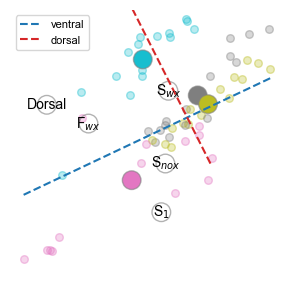

In [27]:
import itertools
import pickle
from compute_RSA import calculate_RSA
from utils.util import filter_rsa_data, init_plot
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
from scipy.spatial import procrustes
import os
from matplotlib.colors import to_rgba
import statsmodels.api as sm

init_plot()

def subjectwise_line(aligned, roi_list, regions):
    indices = [roi_list.index(r) for r in regions if r in roi_list]
    n_sub = aligned.shape[0]

    slopes, intercepts = [], []
    for s in range(n_sub):
        x = aligned[s, indices, 0]
        y = aligned[s, indices, 1]
        m, b = np.polyfit(x, y, 1)
        slopes.append(m)
        intercepts.append(b)

    return np.array(slopes), np.array(intercepts)

def mean_line_with_ci(slopes, intercepts, x_range, ci=95):
    # compute lines for each subject at x_range
    lines = np.array([m * x_range + b for m, b in zip(slopes, intercepts)])
    mean_line = lines.mean(axis=0)
    lower = np.percentile(lines, (100-ci)/2, axis=0)
    upper = np.percentile(lines, 100-(100-ci)/2, axis=0)
    return mean_line, lower, upper

ROIList = ["V1", "EBA", "MTSTS", "SMG_lh"]
roi = ["V1", "EBA", "${\\text{LOT}}_{bio}$", "${\\text{SMG}}_{lh}$"]
condition = ["F_wx", "S_wx", "S_nox", "S_1", "Dorsal"]
conds = ["F$_{wx}$", "S$_{wx}$", "S$_{nox}$", "S$_1$", "Dorsal"]

if os.path.exists("mds.npy"):
    aligned = np.load("mds.npy")
else:
    MRI_RDMs = np.zeros((15, len(ROIList), 6, 6))

    nsub = 0
    for sub in range(2, 18):
        if sub == 8:
            continue
        subject = f"S{sub:02d}"

        for r, region in enumerate(ROIList):
            hem = "all"

            if "SMG" in region:
                region, hem = region.split("_")

            RDM_folder = f"result/fMRI RDM/pearson/{region}"

            if region == "behavior":
                with open(f"{RDM_folder}/RDM_dynamic.pkl", "rb") as File:
                    dynamic_RDM = pickle.load(File)
            else:
                with open(
                    f"{RDM_folder}/{subject}_RDM_{hem}_dynamic.pkl", "rb"
                ) as File:
                    dynamic_RDM = pickle.load(File)

            MRI_RDMs[nsub, r, :, :] = dynamic_RDM
        nsub += 1

    model_RDMs = np.zeros((len(condition), 6, 6))

    for c, cond in enumerate(condition):
        if cond in ["S_wx", "F_wx"]:
            model_name = "slowfast_r50"
        elif cond == "S_nox":
            model_name = "slow_r50"
        elif cond == "dorsal":
            model_name = "dorsalnet"
        else:
            model_name = "res_r50"

        model_path = f"result/model RDM/dynamic/pearson_RDM_{model_name}.pkl"
        with open(model_path, "rb") as pickle_file:
            model_RDM = pickle.load(pickle_file)

        filtered_list = filter_rsa_data(model_RDM, cond)
        indices = [i for i, key in enumerate(model_RDM.keys()) if key in filtered_list]

        model_RDM = np.array(list(model_RDM.values()))
        model_RDM = model_RDM[indices, :, :]
        if "dorsal" in model_name:
            model_RDM = model_RDM[2, :, :]
        else:
            model_RDM = model_RDM[12, :, :]

        model_RDMs[c, :, :] = model_RDM

    model_RDMs = np.repeat(model_RDMs[np.newaxis, :, :, :], 15, axis=0)
    RDMs = np.concatenate((MRI_RDMs, model_RDMs), axis=1)
    whole_RSA = np.ones(
        (15, len(ROIList) + len(condition), len(ROIList) + len(condition))
    )
    combinations = list(itertools.combinations(range(len(ROIList) + len(condition)), 2))
    for s in range(15):
        for c1, c2 in combinations:
            RSA, _ = calculate_RSA(RDMs[s, c1, :, :], RDMs[s, c2, :, :])
            whole_RSA[s, c1, c2] = whole_RSA[s, c2, c1] = RSA

    RDMs = 1 - whole_RSA

    coords_all = []
    for subj in RDMs:
        mds = MDS(
            n_components=2, dissimilarity="precomputed", metric=False, random_state=42
        )
        coords = mds.fit_transform(subj)
        coords_all.append(coords)
        print(f"Stress: {mds.stress_}")
    coords_all = np.array(coords_all)

    ref = coords_all[0]
    aligned = []
    for coords in coords_all:
        mtx1, mtx2, disparity = procrustes(ref, coords)
        aligned.append(mtx2)
    aligned = np.array(aligned)

    np.save("mds.npy", aligned)


theta = np.pi
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])

# apply rotation across last dimension
aligned = aligned @ R.T  # shape (15, 9, 2)


coords_mean = np.mean(aligned, axis=0)

fig = plt.figure(figsize=(7 / 2, 4))

ppc_regions = ["V1", "SMG_lh"]
otc_regions = ["V1", "EBA", "MTSTS"]
slopes_otc, intercepts_otc = subjectwise_line(aligned, ROIList, otc_regions)
x_otc = np.linspace(aligned[:, [ROIList.index(r) for r in otc_regions], 0].min(),
                    aligned[:, [ROIList.index(r) for r in otc_regions], 0].max(),
                    200)
y_otc, lo_otc, hi_otc = mean_line_with_ci(slopes_otc, intercepts_otc, x_otc)
plt.plot(x_otc, y_otc, color="tab:blue", linestyle="--", label="ventral")

# PPC subject-wise regressions
slopes_ppc, intercepts_ppc = subjectwise_line(aligned, ROIList, ppc_regions)
x_ppc = np.linspace(aligned[:, [ROIList.index(r) for r in ppc_regions], 0].min(),
                    aligned[:, [ROIList.index(r) for r in ppc_regions], 0].max(),
                    200)
y_ppc, lo_ppc, hi_ppc = mean_line_with_ci(slopes_ppc, intercepts_ppc, x_ppc)
plt.plot(x_ppc, y_ppc, color="tab:red", linestyle="--", label="dorsal")

colors = ["tab:pink", "tab:gray", "tab:olive", "tab:cyan"]

for subj_coords in aligned:
    for i in range(len(ROIList + condition)):
        if i < len(ROIList):
            face_color = to_rgba(colors[i], alpha=0.3)
            edge_color = to_rgba(colors[i], alpha=0.4)
            plt.scatter(
                subj_coords[i, 0],
                subj_coords[i, 1],
                edgecolors=edge_color,
                s=30,
                color=face_color,
            )

edge_color = to_rgba("gray", alpha=0.6)
plt.scatter(
    coords_mean[: len(ROIList), 0],
    coords_mean[: len(ROIList), 1],
    c=colors,
    s=180,
    edgecolor=edge_color,
)

plt.scatter(
    coords_mean[len(ROIList) :, 0],
    coords_mean[len(ROIList) :, 1],
    c="none",
    s=180,
    alpha=0.6,
    edgecolor="gray",
)

for i, txt in enumerate(conds):
    text = plt.text(
        coords_mean[len(ROIList) + i, 0],
        coords_mean[len(ROIList) + i, 1],
        txt,
        ha="center",
        va="center",
    )

plt.xlim(-0.3, 0.3)
plt.ylim(-0.4, 0.3)
plt.gca().set_aspect("auto", adjustable="box")
plt.gca().set_box_aspect(1)
# ax_scatter.axis('square')

plt.xticks([])
plt.yticks([])

for spine in plt.gca().spines.values():
    spine.set_visible(False)

# h, _ = plt.gca().get_legend_handles_labels()
# plt.legend(
#     h,
#     roi,
#     ncols=4,
#     loc="lower center",
#     frameon=False,
#     bbox_to_anchor=(0.5, -0.1),
#     columnspacing=0.8,
#     handletextpad=0.3,
# )
plt.legend()